###**Introduction**:
YouTube is one of the world’s largest digital content platforms, with millions of creators generating content across multiple categories such as entertainment, music, gaming, education, and technology. Analyzing YouTube channel statistics can provide valuable insights into audience behavior, content trends, subscriber growth, video engagement, and revenue generation.

This project focuses on performing Exploratory Data Analysis (EDA) on the Global YouTube Statistics dataset using Python libraries such as Pandas, Matplotlib, and Seaborn. The project aims to analyze trends, patterns, correlations, and performance metrics of YouTube channels worldwide through statistical analysis and data visualization techniques.

The analysis includes subscriber trends, video views, channel categories, earnings, uploads, country-wise performance, and audience growth patterns to better understand the dynamics of digital content creation and monetization.

###**Objective**:
The main objective of this project is to perform Exploratory Data Analysis (EDA) on YouTube channel statistics to uncover meaningful trends, patterns, and business insights.

The specific objectives are:

• Analyze subscriber growth, video views, uploads, and earnings of YouTube channels

• Perform data cleaning and preprocessing techniques on the dataset

• Identify relationships and correlations between key performance metrics

• Explore category-wise and country-wise channel performance

• Visualize trends and audience behavior using statistical graphs and plots

• Understand the impact of subscribers, uploads, and video views on channel earnings

• Generate meaningful insights through statistical and visual analysis

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Load Dataset**

In [2]:
df = pd.read_csv('Global YouTube Statistics.csv', encoding='latin1')
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [3]:
print("Shape of dataset:", df.shape)

Shape of dataset: (995, 28)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    object 
 5   Title                                    995 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    object 
 8   Abbreviation                             873 non-null    object 
 9   channel_type                             965 non-null    object 
 10  video_views_rank                         994 non-n

**Checking missing values and suplicate rows**

In [5]:
df.isnull().sum()

,0
rank,0
Youtuber,0
subscribers,0
video views,0
category,46
Title,0
uploads,0
Country,122
Abbreviation,122
channel_type,30


In [6]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


**Data Cleaning**

In [7]:
df = df.drop_duplicates()

**Handling Missing Values in categorical columns**

In [8]:
df['category'] = df['category'].fillna(df['category'].mode()[0])

df['Country'] = df['Country'].fillna('Unknown')

df['Abbreviation'] = df['Abbreviation'].fillna('Unknown')

df['channel_type'] = df['channel_type'].fillna(df['channel_type'].mode()[0])

df['created_month'] = df['created_month'].fillna(df['created_month'].mode()[0])

**Handling Missing Values in Numerical Columns**

In [9]:
numeric_columns = [
    'video_views_rank',
    'country_rank',
    'channel_type_rank',
    'video_views_for_the_last_30_days',
    'subscribers_for_last_30_days',
    'created_year',
    'created_date',
    'Gross tertiary education enrollment (%)',
    'Population',
    'Unemployment rate',
    'Urban_population',
    'Latitude',
    'Longitude'
]
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [10]:
df.isnull().sum()

,0
rank,0
Youtuber,0
subscribers,0
video views,0
category,0
Title,0
uploads,0
Country,0
Abbreviation,0
channel_type,0


###**Statistical Summary**

In [11]:
df.describe()

,rank,subscribers,video views,uploads,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,...,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
count,995.00000,9.950000e+02,9.950000e+02,995.000000,9.950000e+02,995.00000,995.000000,9.950000e+02,995.000000,9.950000e+02,...,9.950000e+02,9.950000e+02,995.000000,995.000000,995.000000,9.950000e+02,995.000000,9.950000e+02,995.000000,995.000000
mean,498.00000,2.298241e+07,1.103954e+10,9187.125628,5.536928e+05,346.99196,723.159296,1.693335e+08,36886.148281,5.898078e+05,...,7.081814e+06,2.985870e+05,2012.632161,15.747739,64.168241,4.177600e+08,9.289874,2.299568e+08,27.925514,-18.800556
std,287.37606,1.752611e+07,1.411084e+10,34151.352254,1.362209e+06,1163.09926,1915.718317,4.052958e+08,71858.724092,1.148622e+06,...,1.379704e+07,5.044333e+05,4.501215,8.755434,24.480683,4.438532e+08,4.576008,1.456064e+08,19.552101,80.313810
min,1.00000,1.230000e+07,0.000000e+00,0.000000,1.000000e+00,1.00000,1.000000,1.000000e+00,0.000000,0.000000e+00,...,0.000000e+00,1.000000e+00,1970.000000,1.000000,7.600000,2.025060e+05,0.750000,3.558800e+04,-38.416097,-172.104629
25%,249.50000,1.450000e+07,4.288145e+09,194.500000,3.240000e+02,14.00000,28.000000,2.232300e+07,2700.000000,4.350000e+04,...,5.217500e+05,1.000000e+05,2009.000000,8.000000,40.200000,1.260140e+08,5.360000,1.026269e+08,20.593684,-95.712891
50%,498.00000,1.770000e+07,7.760820e+09,729.000000,9.155000e+02,51.00000,65.500000,6.408500e+07,13300.000000,2.127000e+05,...,2.600000e+06,2.000000e+05,2013.000000,16.000000,68.000000,3.282395e+08,9.365000,2.706630e+08,37.090240,-51.925280
75%,746.50000,2.460000e+07,1.355470e+10,2667.500000,3.579000e+03,114.00000,137.000000,1.585655e+08,37900.000000,6.068000e+05,...,7.300000e+06,2.000000e+05,2016.000000,23.000000,88.200000,3.282395e+08,14.700000,2.706630e+08,37.090240,78.962880
max,995.00000,2.450000e+08,2.280000e+11,301308.000000,4.057944e+06,7741.00000,7741.000000,6.589000e+09,850900.000000,1.360000e+07,...,1.634000e+08,8.000000e+06,2022.000000,31.000000,113.100000,1.397715e+09,14.720000,8.429340e+08,61.924110,138.252924


In [13]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

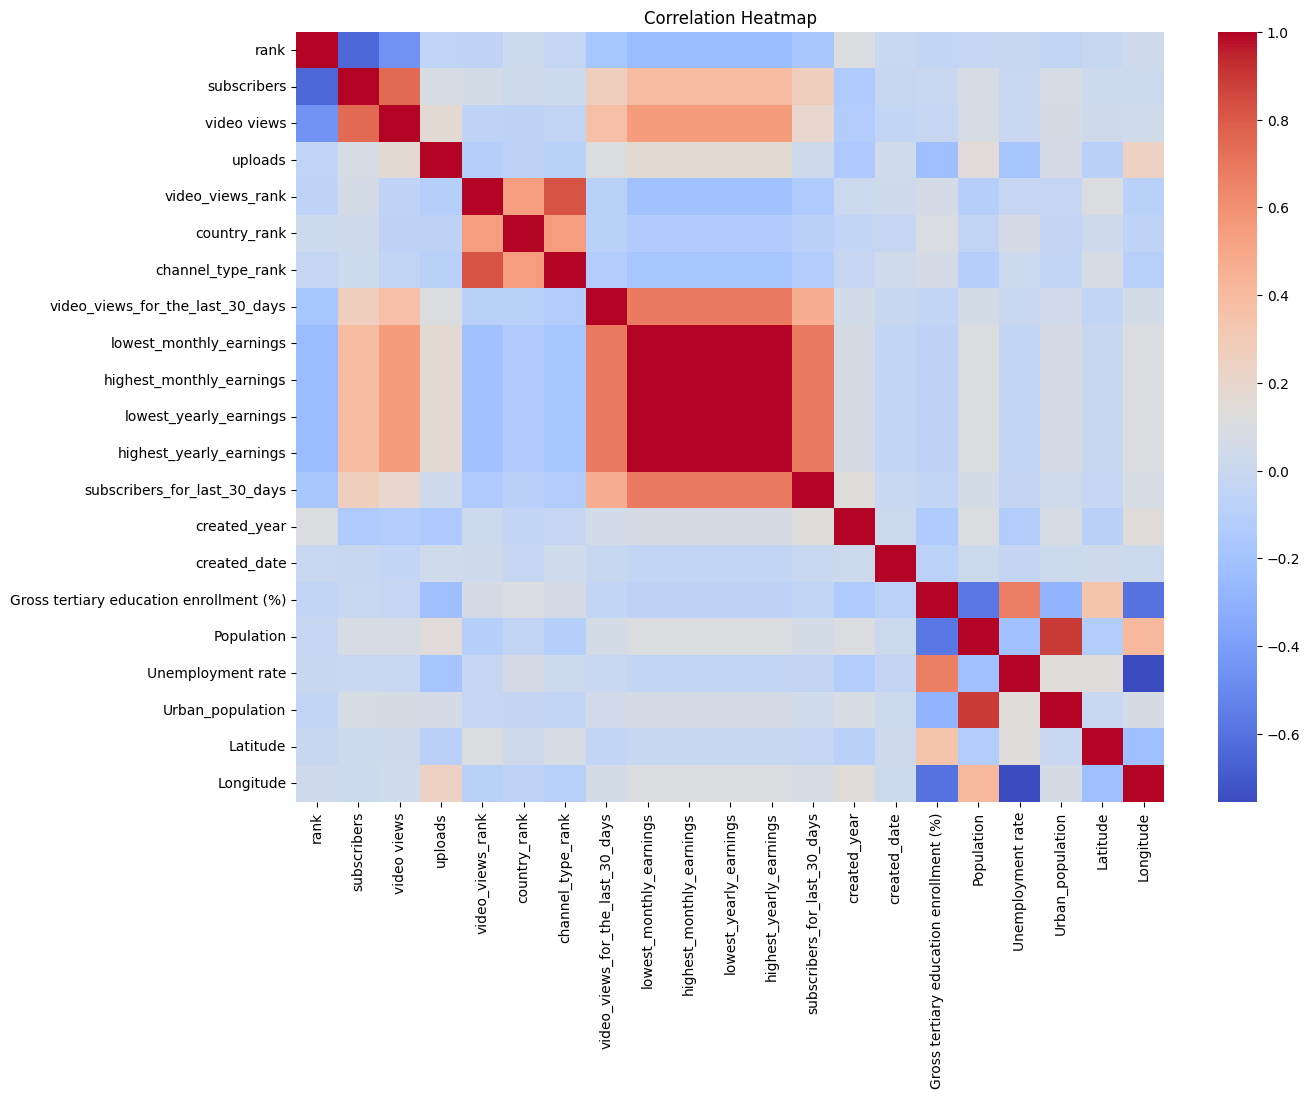

In [14]:
plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [16]:
numeric_df.corr()

,rank,subscribers,video views,uploads,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,...,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
rank,1.000000,-0.640608,-0.453363,-0.051036,-0.059768,0.021302,-0.026937,-0.179865,-0.248394,-0.248050,...,-0.248392,-0.172445,0.105961,-0.006226,-0.038976,-0.018691,-0.014322,-0.043171,-0.011785,0.027971
subscribers,-0.640608,1.000000,0.750958,0.077136,0.057388,0.029425,0.025259,0.269655,0.388941,0.388579,...,0.388935,0.270055,-0.141895,-0.011873,-0.005342,0.076693,-0.007747,0.081201,0.021643,0.018152
video views,-0.453363,0.750958,1.000000,0.165928,-0.061542,-0.062727,-0.047211,0.362882,0.552096,0.551455,...,0.552091,0.192514,-0.127119,-0.038201,-0.017093,0.081297,-0.000943,0.070941,0.029576,0.036033
uploads,-0.051036,0.077136,0.165928,1.000000,-0.108865,-0.069129,-0.094964,0.105267,0.166922,0.167283,...,0.166904,0.027984,-0.154985,0.034854,-0.222611,0.149267,-0.187815,0.062066,-0.083270,0.244046
video_views_rank,-0.059768,0.057388,-0.061542,-0.108865,1.000000,0.543728,0.815824,-0.091453,-0.208609,-0.208681,...,-0.208597,-0.139417,0.007332,0.031144,0.063684,-0.110346,-0.016388,-0.024405,0.107208,-0.095559
country_rank,0.021302,0.029425,-0.062727,-0.069129,0.543728,1.000000,0.544633,-0.093128,-0.132893,-0.132924,...,-0.132886,-0.089790,-0.040733,-0.017364,0.097342,-0.045899,0.065451,-0.033271,0.032432,-0.057469
channel_type_rank,-0.026937,0.025259,-0.047211,-0.094964,0.815824,0.544633,1.000000,-0.129117,-0.180626,-0.180685,...,-0.180615,-0.118579,-0.016674,0.036865,0.066770,-0.109473,0.006151,-0.039818,0.079695,-0.101427
video_views_for_the_last_30_days,-0.179865,0.269655,0.362882,0.105267,-0.091453,-0.093128,-0.129117,1.000000,0.681555,0.681514,...,0.681556,0.467034,0.052834,-0.012900,-0.039566,0.059812,-0.002540,0.044839,-0.037437,0.058717
lowest_monthly_earnings,-0.248394,0.388941,0.552096,0.166922,-0.208609,-0.132893,-0.180626,0.681555,1.000000,0.999955,...,0.999998,0.679738,0.072054,-0.040317,-0.064128,0.105925,-0.041277,0.067560,-0.009226,0.107764
highest_monthly_earnings,-0.248050,0.388579,0.551455,0.167283,-0.208681,-0.132924,-0.180685,0.681514,0.999955,1.000000,...,0.999953,0.680067,0.072028,-0.040007,-0.063919,0.105899,-0.041045,0.067599,-0.008933,0.107677


###**Video View Trends and Patterns**

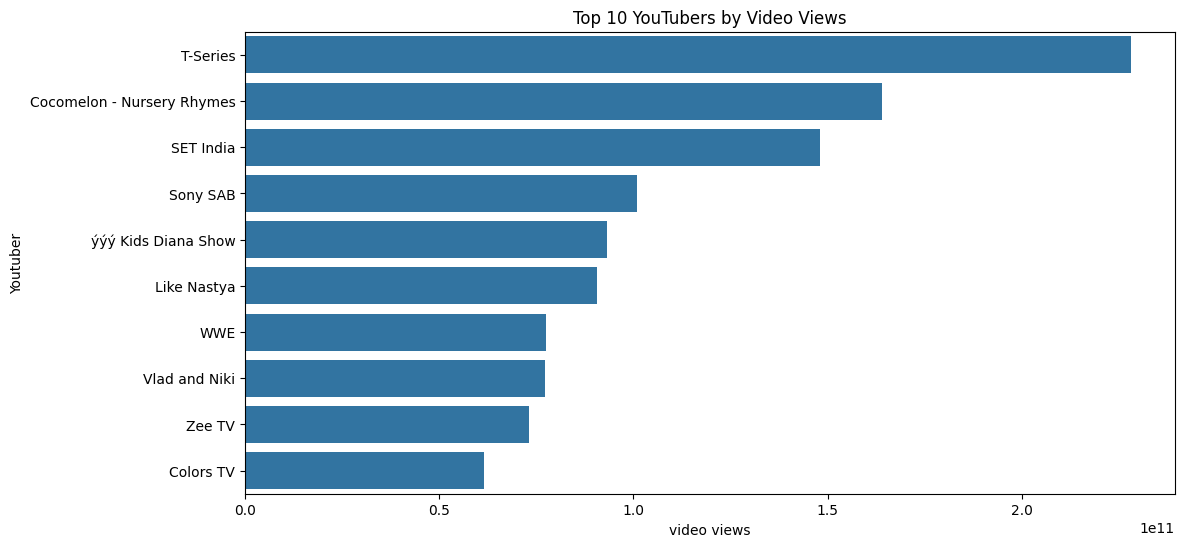

In [17]:
top_views = df.sort_values(
    by='video views',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='video views',
    y='Youtuber',
    data=top_views
)
plt.title("Top 10 YouTubers by Video Views")
plt.show()

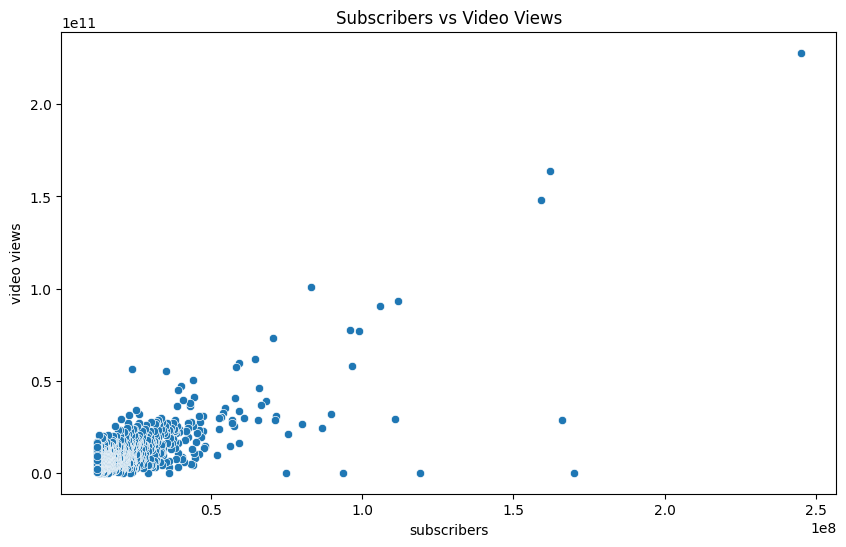

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='subscribers',
    y='video views',
    data=df
)
plt.title("Subscribers vs Video Views")
plt.show()

**Category Analysis**

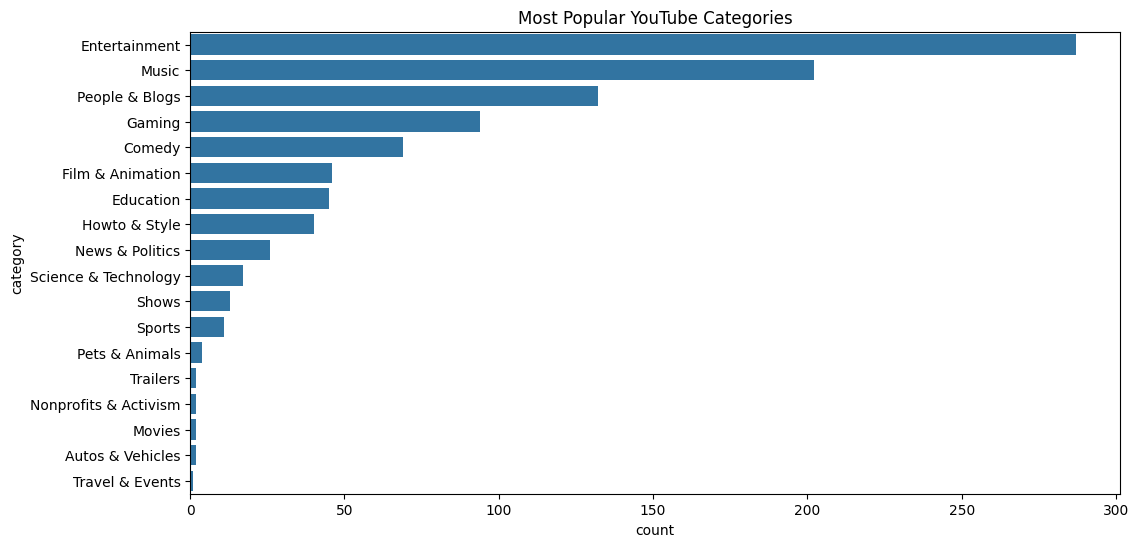

In [19]:
plt.figure(figsize=(12,6))
sns.countplot(
    y='category',
    data=df,
    order=df['category'].value_counts().index
)
plt.title("Most Popular YouTube Categories")
plt.show()

**Country-Based Analysis**

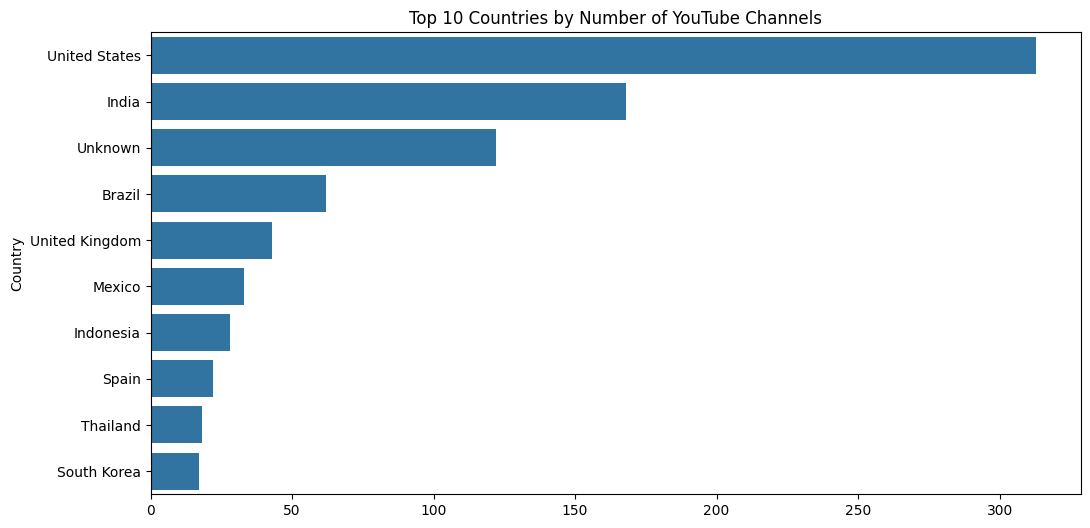

In [20]:
top_countries = df['Country'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)
plt.title("Top 10 Countries by Number of YouTube Channels")
plt.show()

**Earnings Analysis**

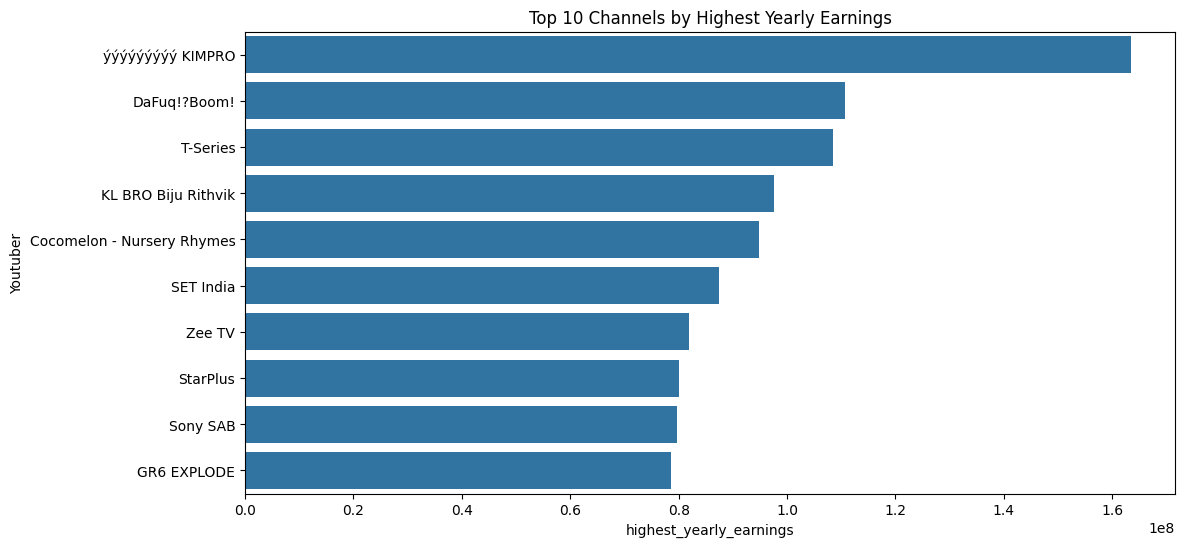

In [22]:
top_earnings = df.sort_values(
    by='highest_yearly_earnings',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='highest_yearly_earnings',
    y='Youtuber',
    data=top_earnings
)

plt.title("Top 10 Channels by Highest Yearly Earnings")
plt.show()

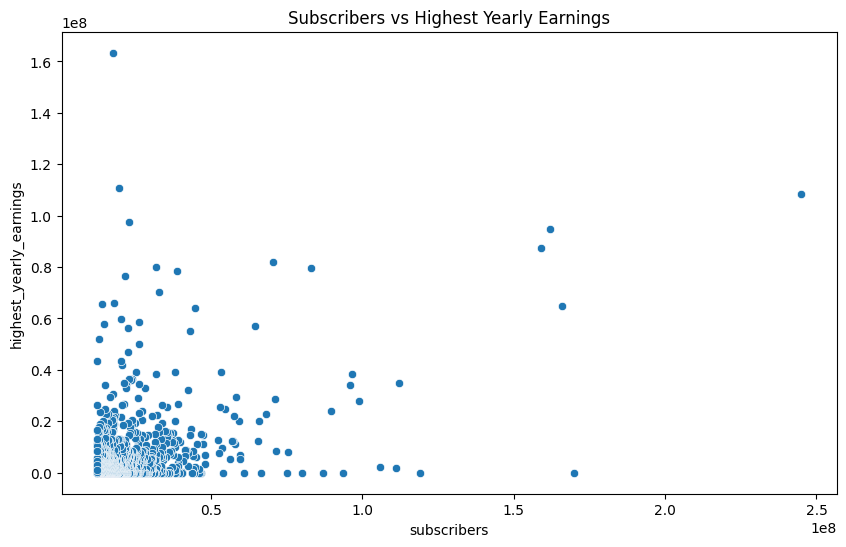

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='subscribers',
    y='highest_yearly_earnings',
    data=df
)

plt.title("Subscribers vs Highest Yearly Earnings")

plt.show()

**Distribution Analysis**

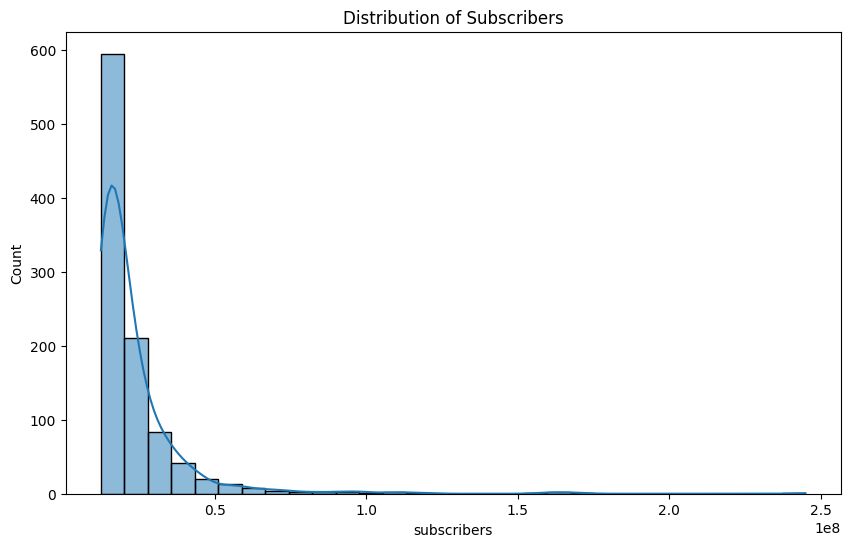

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['subscribers'],
    bins=30,
    kde=True
)

plt.title("Distribution of Subscribers")

plt.show()

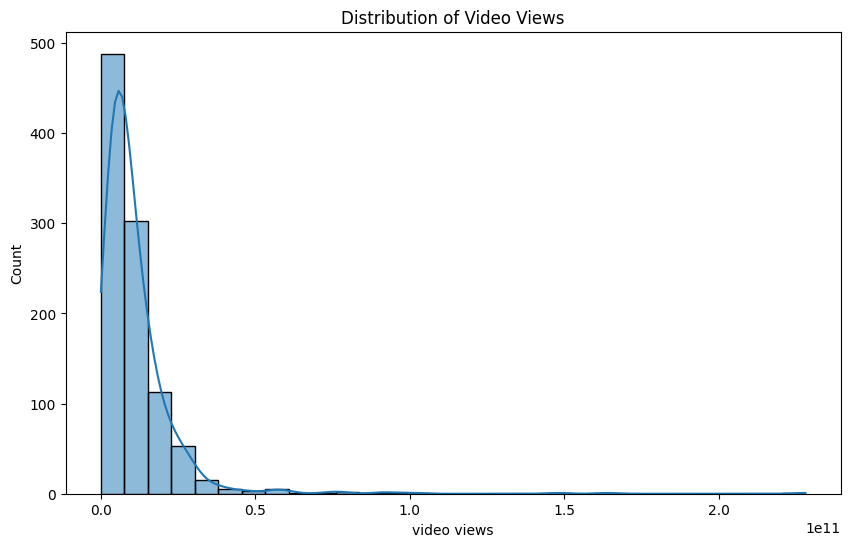

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['video views'],
    bins=30,
    kde=True
)

plt.title("Distribution of Video Views")

plt.show()

**Outlier Analysis**

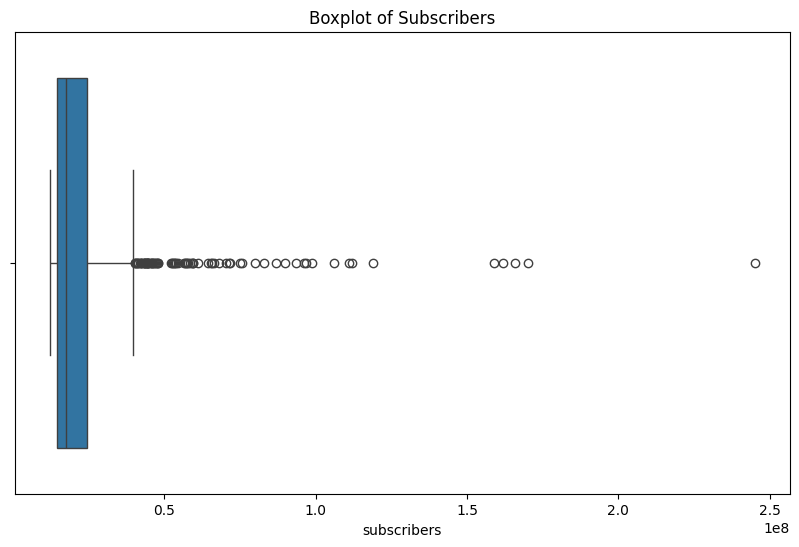

In [26]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['subscribers']
)

plt.title("Boxplot of Subscribers")

plt.show()

**Pattern Analysis**

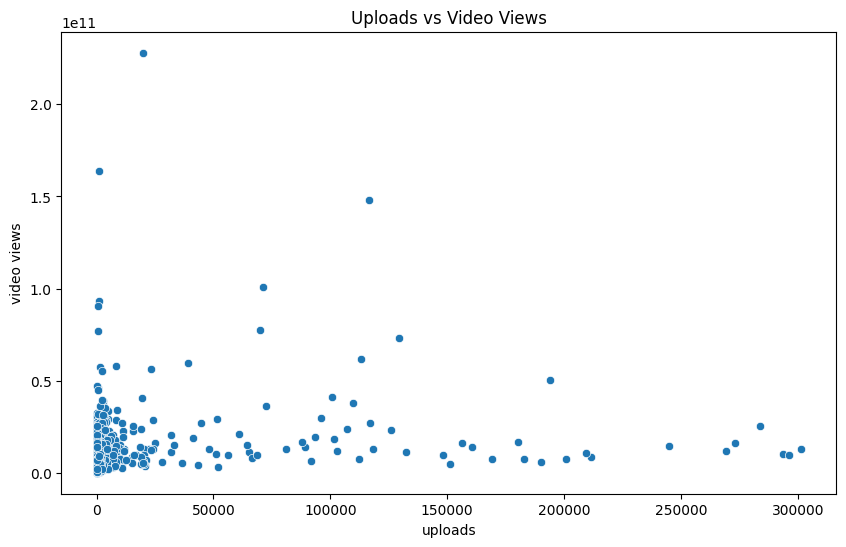

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='uploads',
    y='video views',
    data=df
)

plt.title("Uploads vs Video Views")

plt.show()

**Percentage Analysis**

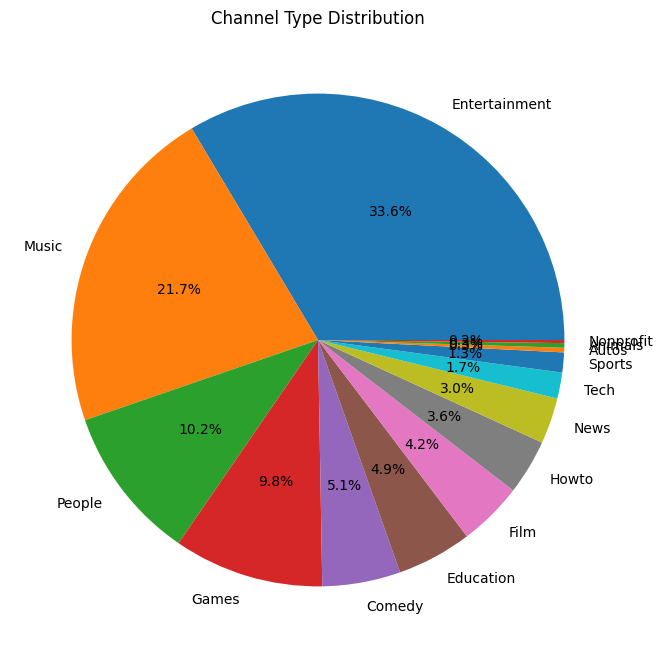

In [29]:
channel_counts = df['channel_type'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    channel_counts,
    labels=channel_counts.index,
    autopct='%1.1f%%'
)

plt.title("Channel Type Distribution")

plt.show()

**Trend Analysis**

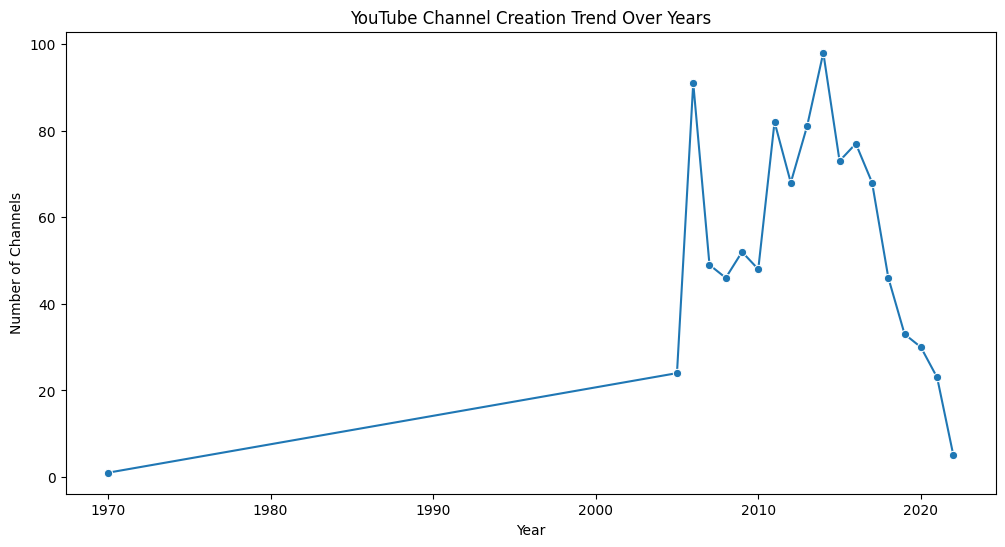

In [30]:
year_trend = df['created_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=year_trend.index,
    y=year_trend.values,
    marker='o'
)

plt.title("YouTube Channel Creation Trend Over Years")

plt.xlabel("Year")
plt.ylabel("Number of Channels")

plt.show()

**Monthly Pattern Analysis**

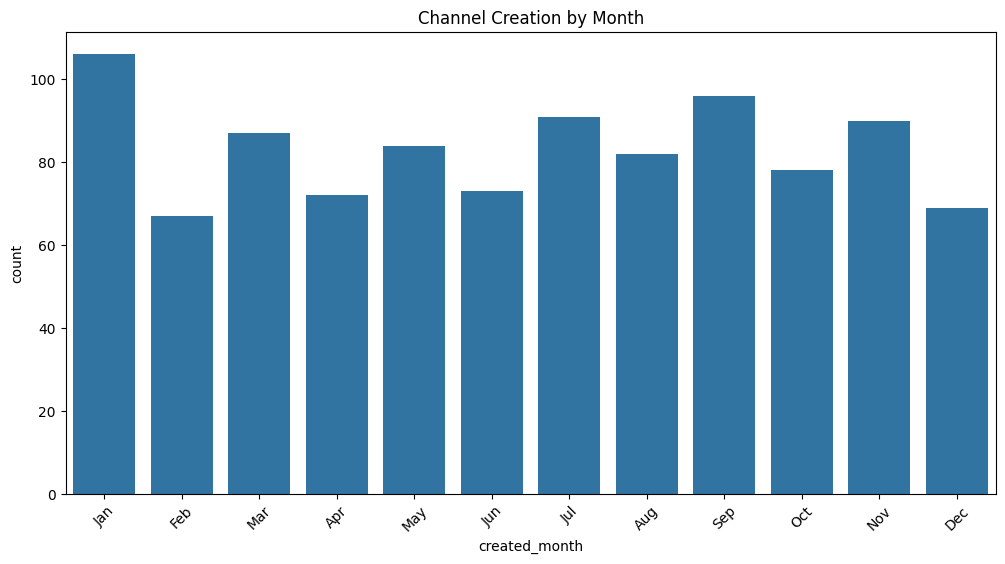

In [37]:
month_order = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

plt.figure(figsize=(12,6))

sns.countplot(
    x='created_month',
    data=df,
    order=month_order
)

plt.title("Channel Creation by Month")

plt.xticks(rotation=45)

plt.show()

**Channel Type Analysis**

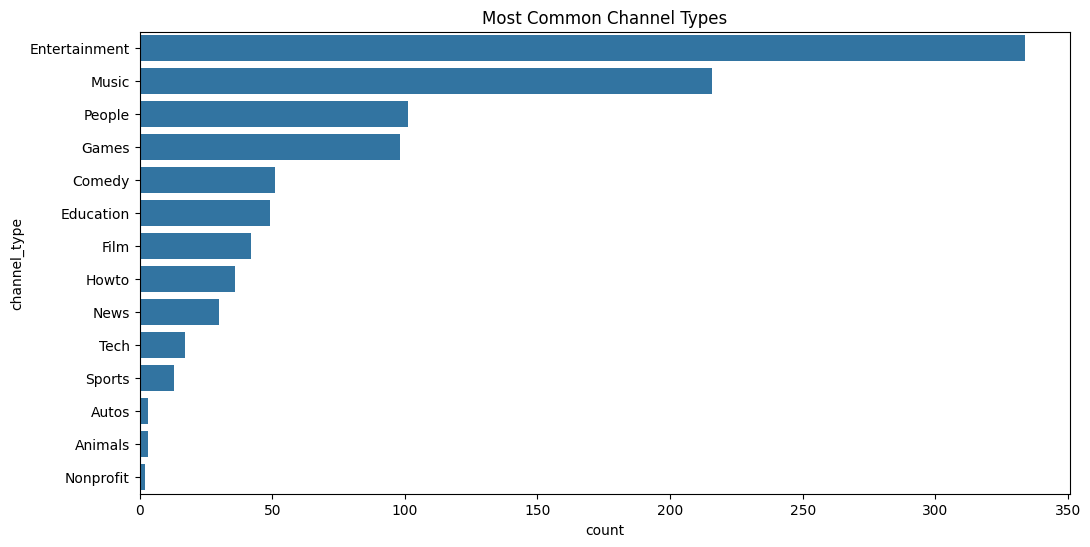

In [32]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='channel_type',
    data=df,
    order=df['channel_type'].value_counts().index
)

plt.title("Most Common Channel Types")

plt.show()

**Ranking Analysis**

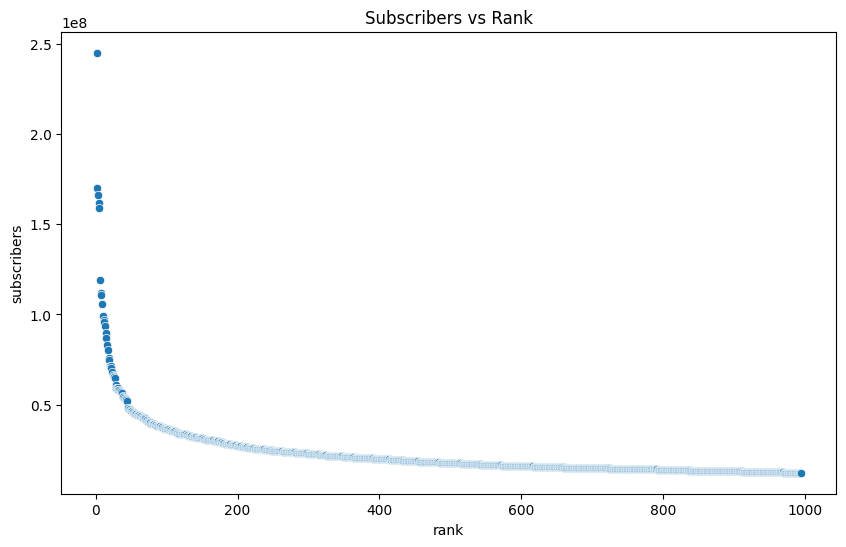

In [34]:
plt.figure(figsize=(10,6))

sns.scatterplot( x='rank', y='subscribers', data=df )

plt.title("Subscribers vs Rank")

plt.show()

**Earnings Distribution Analysis**

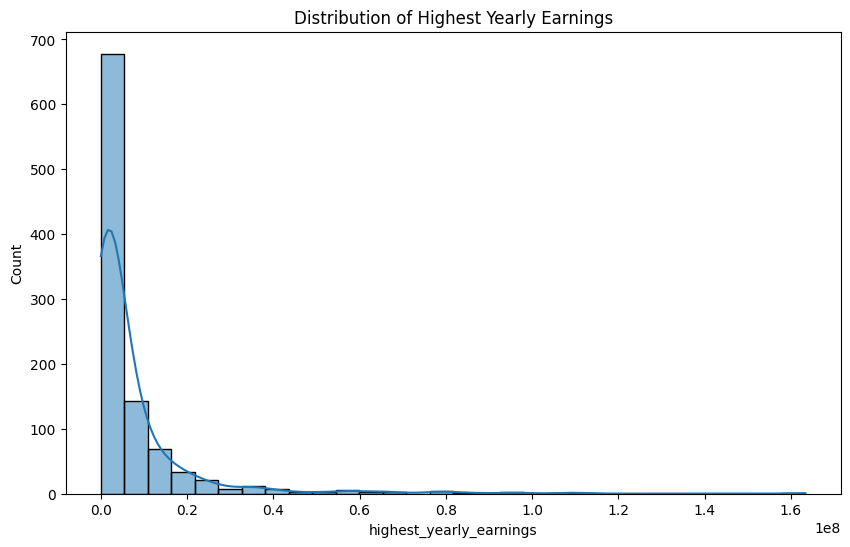

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['highest_yearly_earnings'],
    bins=30,
    kde=True
)

plt.title("Distribution of Highest Yearly Earnings")

plt.show()

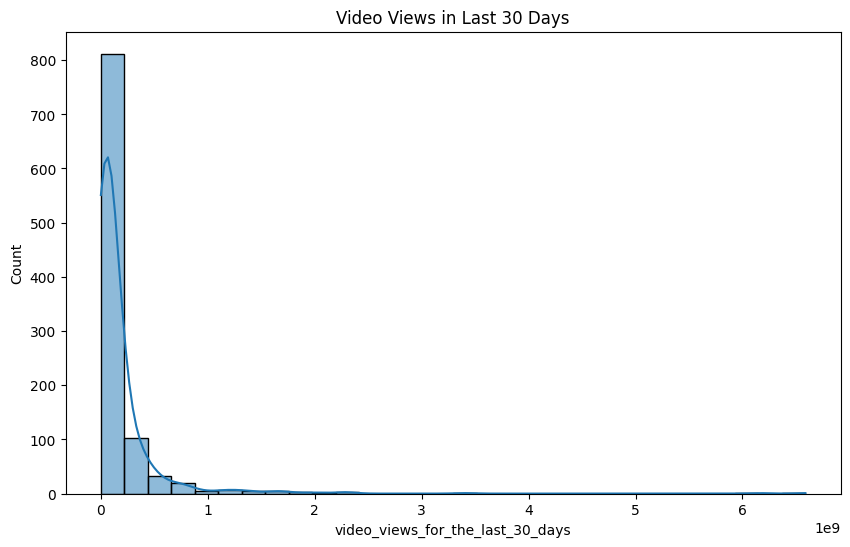

In [39]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['video_views_for_the_last_30_days'],
    bins=30,
    kde=True
)

plt.title("Video Views in Last 30 Days")

plt.show()

**Relationship Analysis**

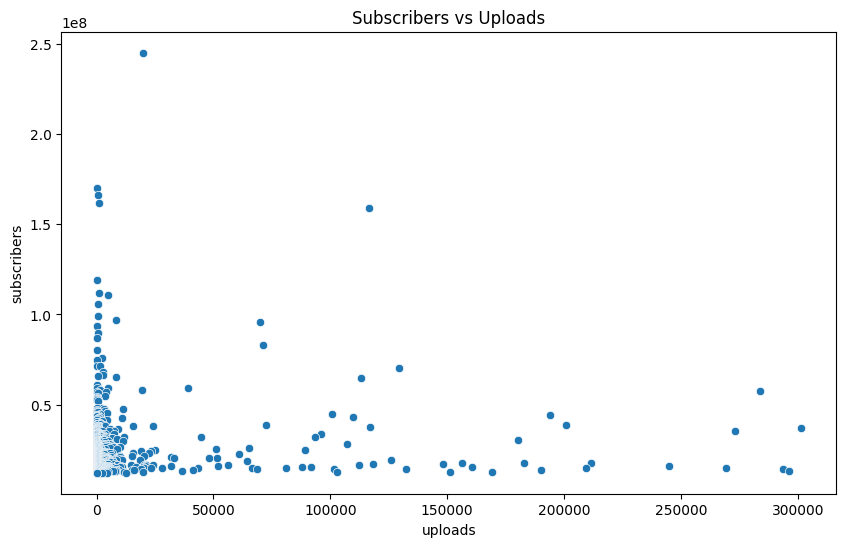

In [40]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='uploads',
    y='subscribers',
    data=df
)

plt.title("Subscribers vs Uploads")

plt.show()

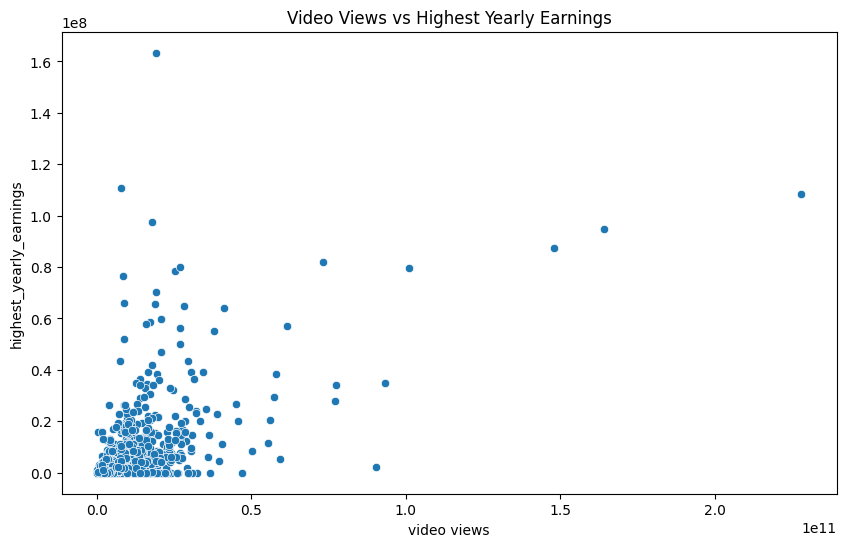

In [41]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='video views',
    y='highest_yearly_earnings',
    data=df
)

plt.title("Video Views vs Highest Yearly Earnings")

plt.show()

**Comparative Analysis**

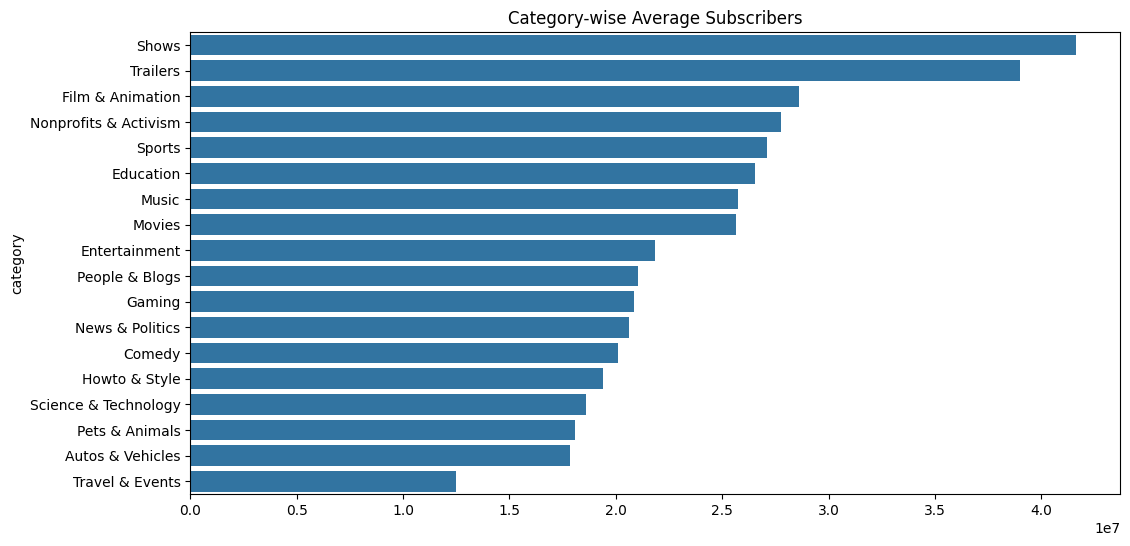

In [42]:
category_subscribers = df.groupby('category')['subscribers'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_subscribers.values,
    y=category_subscribers.index
)

plt.title("Category-wise Average Subscribers")

plt.show()

**Country-wise Earnings Analysis**

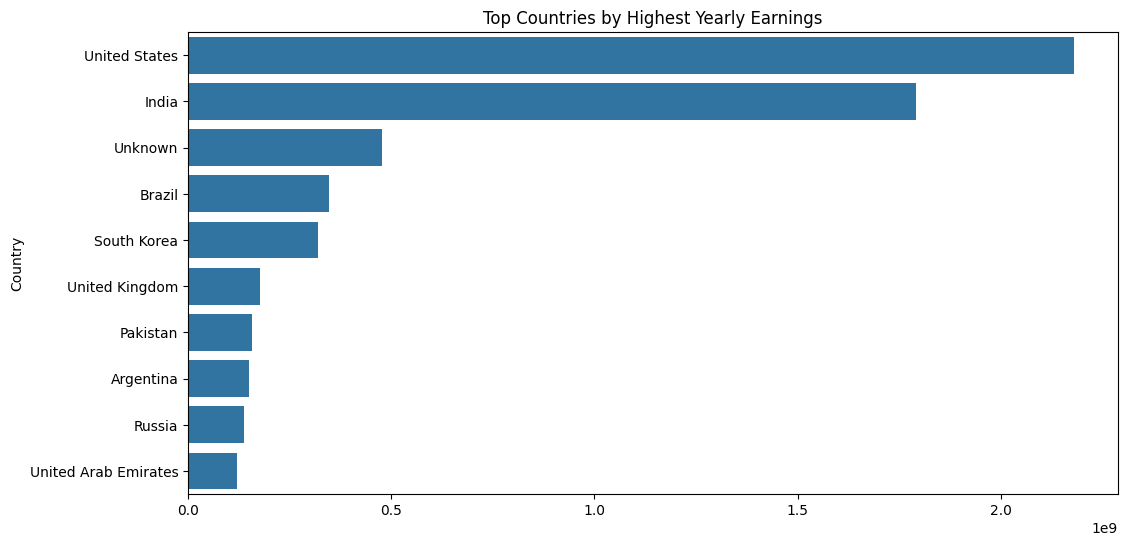

In [43]:
country_earnings = df.groupby('Country')['highest_yearly_earnings'].sum().sort_values(
    ascending=False
).head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=country_earnings.values,
    y=country_earnings.index
)
plt.title("Top Countries by Highest Yearly Earnings")
plt.show()

**Upload Analysis**

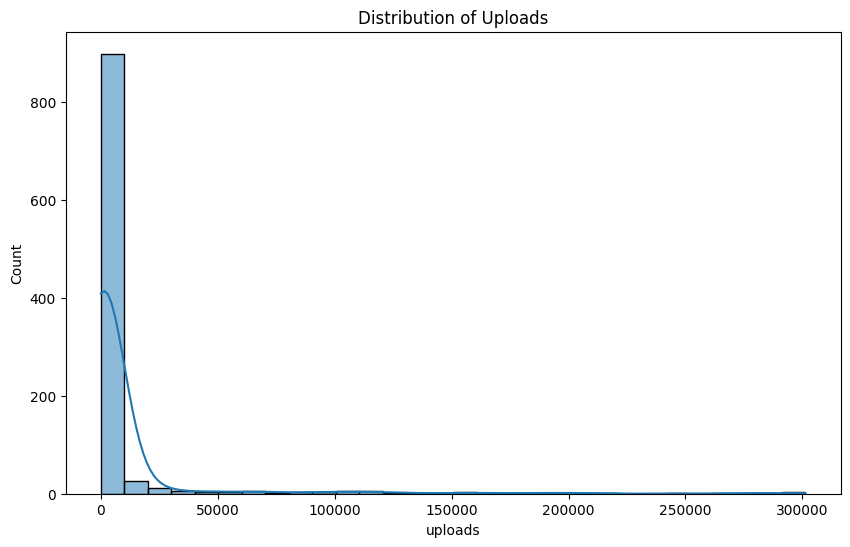

In [44]:
plt.figure(figsize=(10,6))
sns.histplot(
    df['uploads'],
    bins=30,
    kde=True
)
plt.title("Distribution of Uploads")
plt.show()

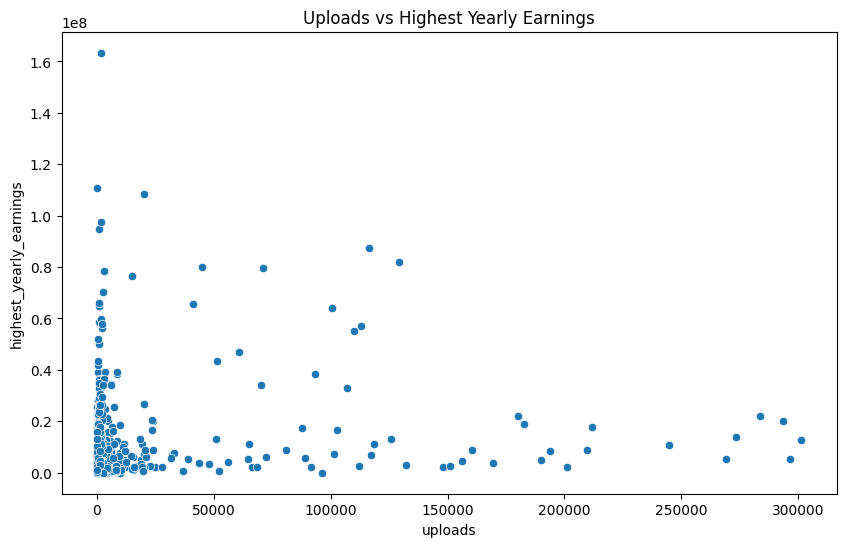

In [45]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='uploads',
    y='highest_yearly_earnings',
    data=df
)

plt.title("Uploads vs Highest Yearly Earnings")

plt.show()

**Ranking Trend Analysis**

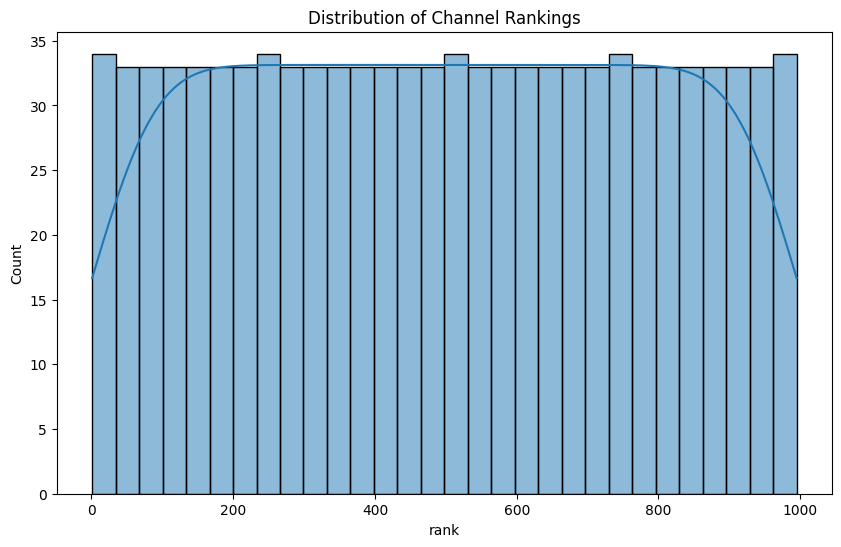

In [46]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['rank'],
    bins=30,
    kde=True
)

plt.title("Distribution of Channel Rankings")

plt.show()

**Comparative Statistical Analysis**

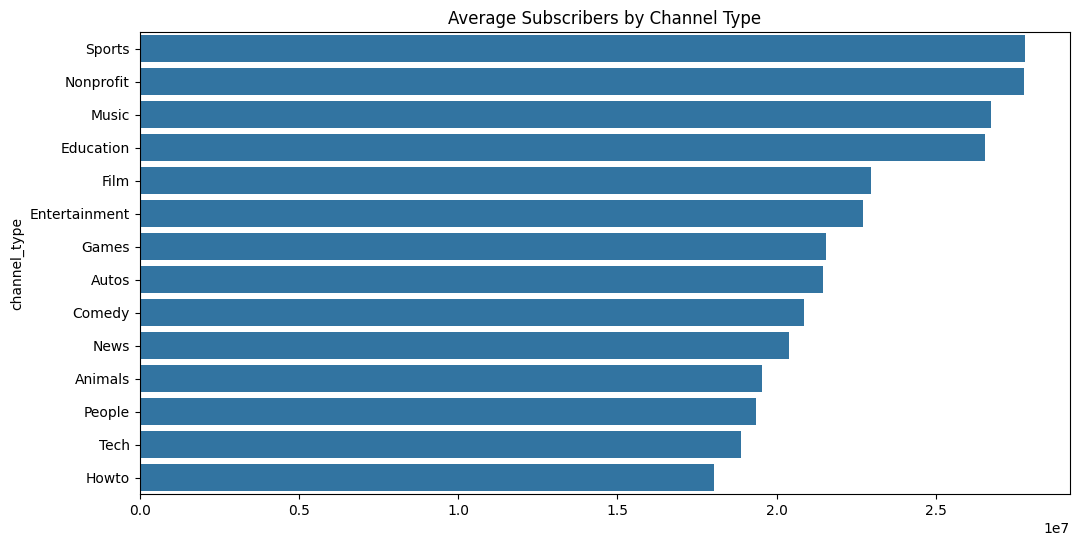

In [47]:
channel_subscribers = df.groupby('channel_type')['subscribers'].mean().sort_values(
    ascending=False
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=channel_subscribers.values,
    y=channel_subscribers.index
)
plt.title("Average Subscribers by Channel Type")
plt.show()

###**Advanced Pattern Analysis**
**Correlation Between Uploads, Subscribers, and Video Views**

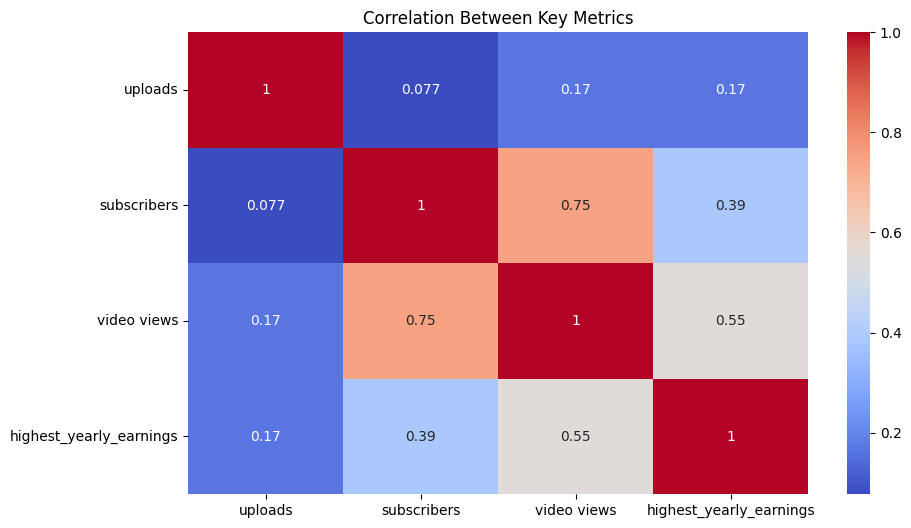

In [48]:
selected_columns = [
    'uploads',
    'subscribers',
    'video views',
    'highest_yearly_earnings'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df[selected_columns].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between Key Metrics")

plt.show()

**Revenue Trend Analysis**

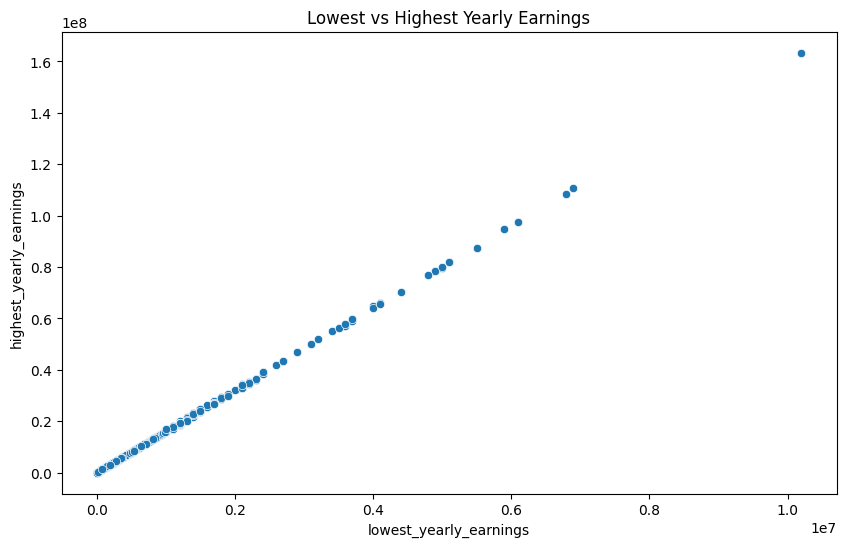

In [50]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='lowest_yearly_earnings',
    y='highest_yearly_earnings',
    data=df
)

plt.title("Lowest vs Highest Yearly Earnings")

plt.show()

**Subscriber Ranking Patterns**

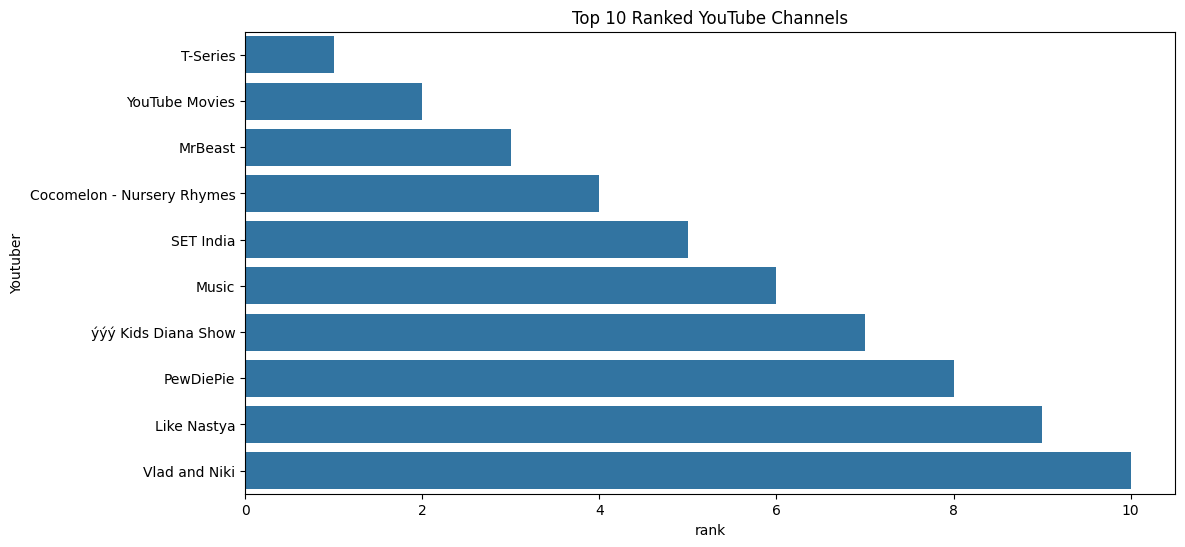

In [51]:
top_ranked = df.sort_values(
    by='rank'
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='rank',
    y='Youtuber',
    data=top_ranked
)

plt.title("Top 10 Ranked YouTube Channels")

plt.show()

**Comparative Growth Analysis**

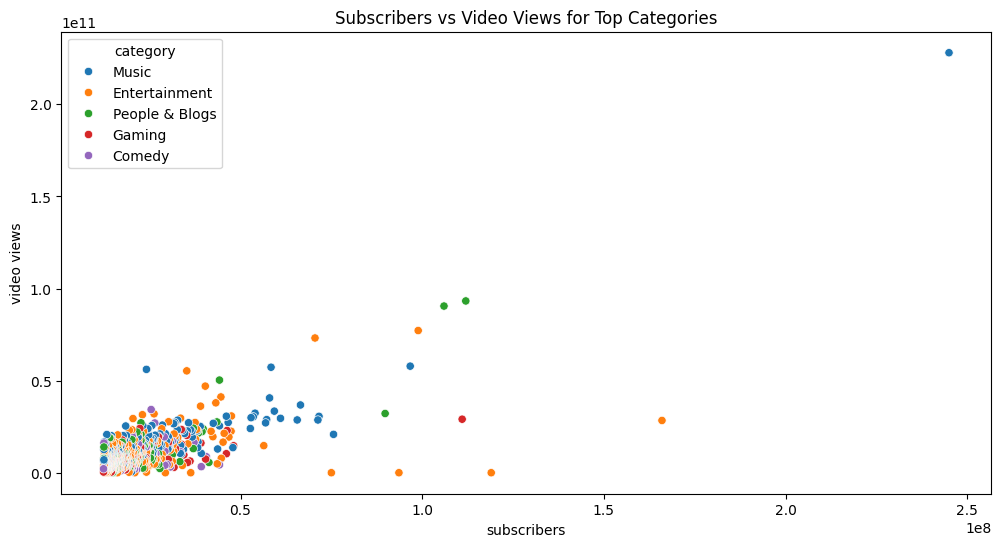

In [52]:
top_categories = df['category'].value_counts().head(5).index

filtered_df = df[df['category'].isin(top_categories)]

plt.figure(figsize=(12,6))

sns.scatterplot(
    x='subscribers',
    y='video views',
    hue='category',
    data=filtered_df
)

plt.title("Subscribers vs Video Views for Top Categories")

plt.show()

**Country Trend Analysis**

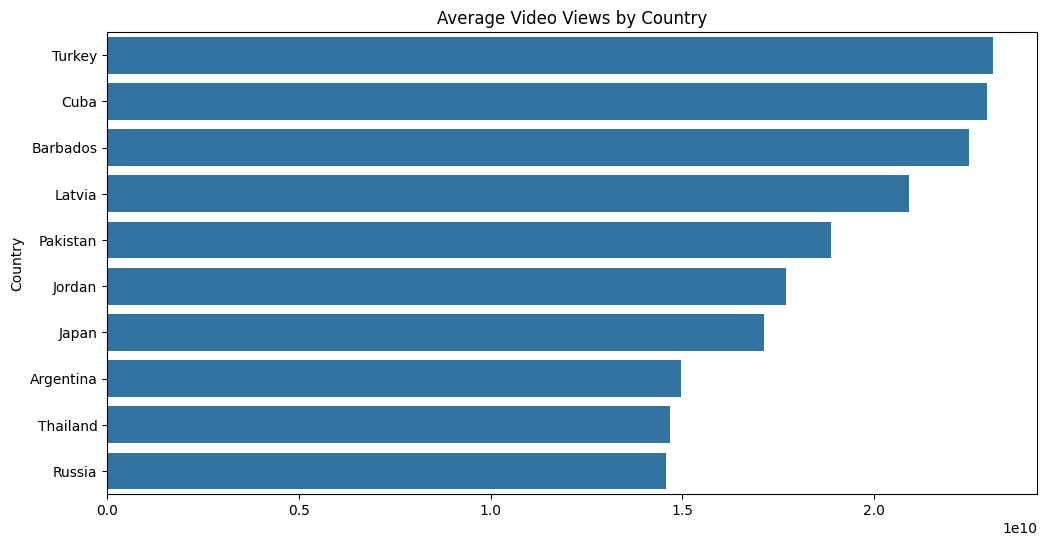

In [53]:
country_views = df.groupby('Country')['video views'].mean().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_views.values,
    y=country_views.index
)

plt.title("Average Video Views by Country")

plt.show()

**Earnings Pattern Analysis**

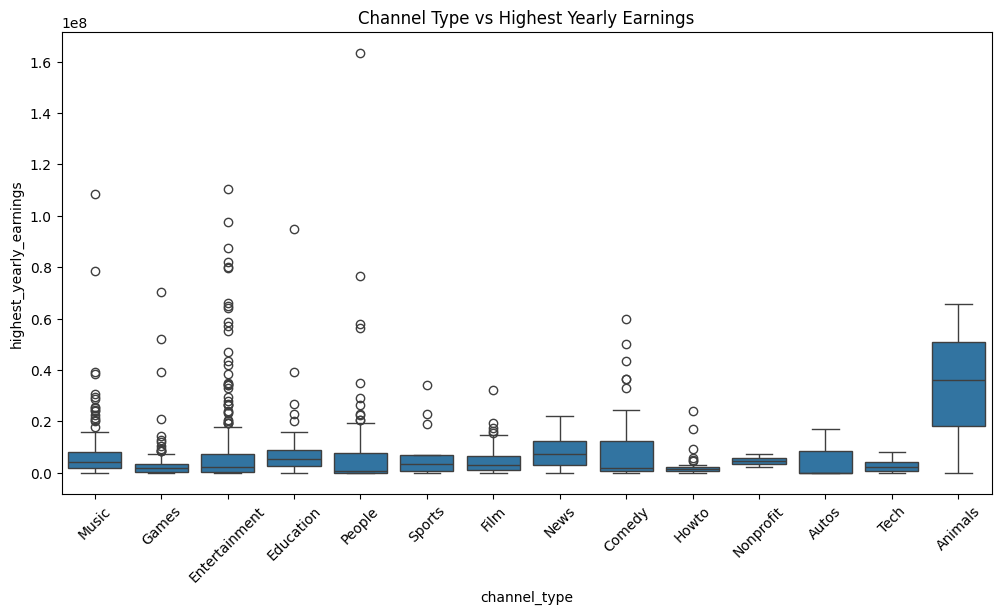

In [54]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='channel_type',
    y='highest_yearly_earnings',
    data=df
)

plt.xticks(rotation=45)

plt.title("Channel Type vs Highest Yearly Earnings")

plt.show()

**Upload Frequency Analysis**

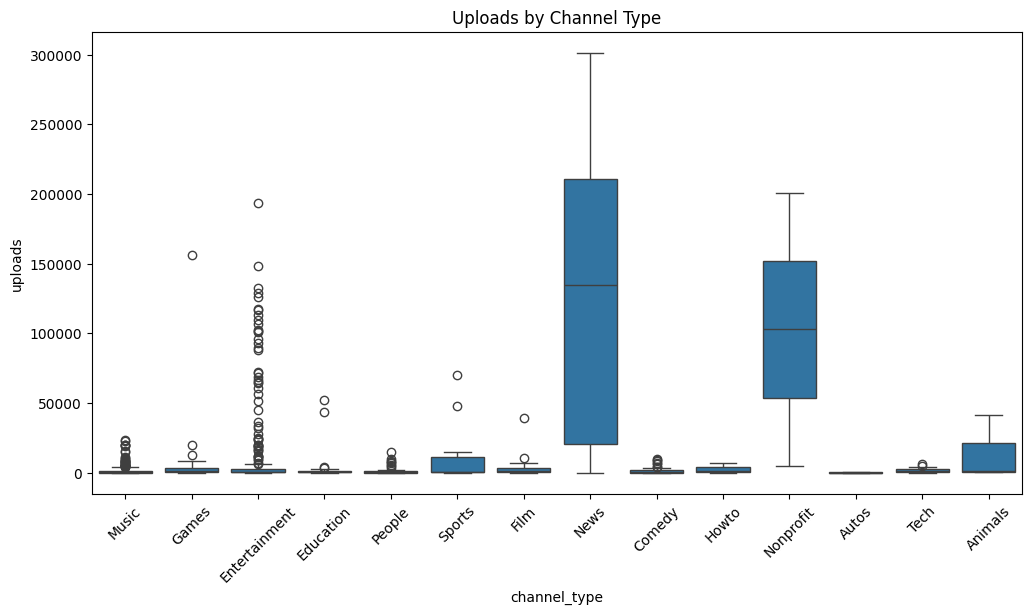

In [55]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='channel_type',
    y='uploads',
    data=df
)

plt.xticks(rotation=45)

plt.title("Uploads by Channel Type")

plt.show()

###**Final EDA Summary Visualization**

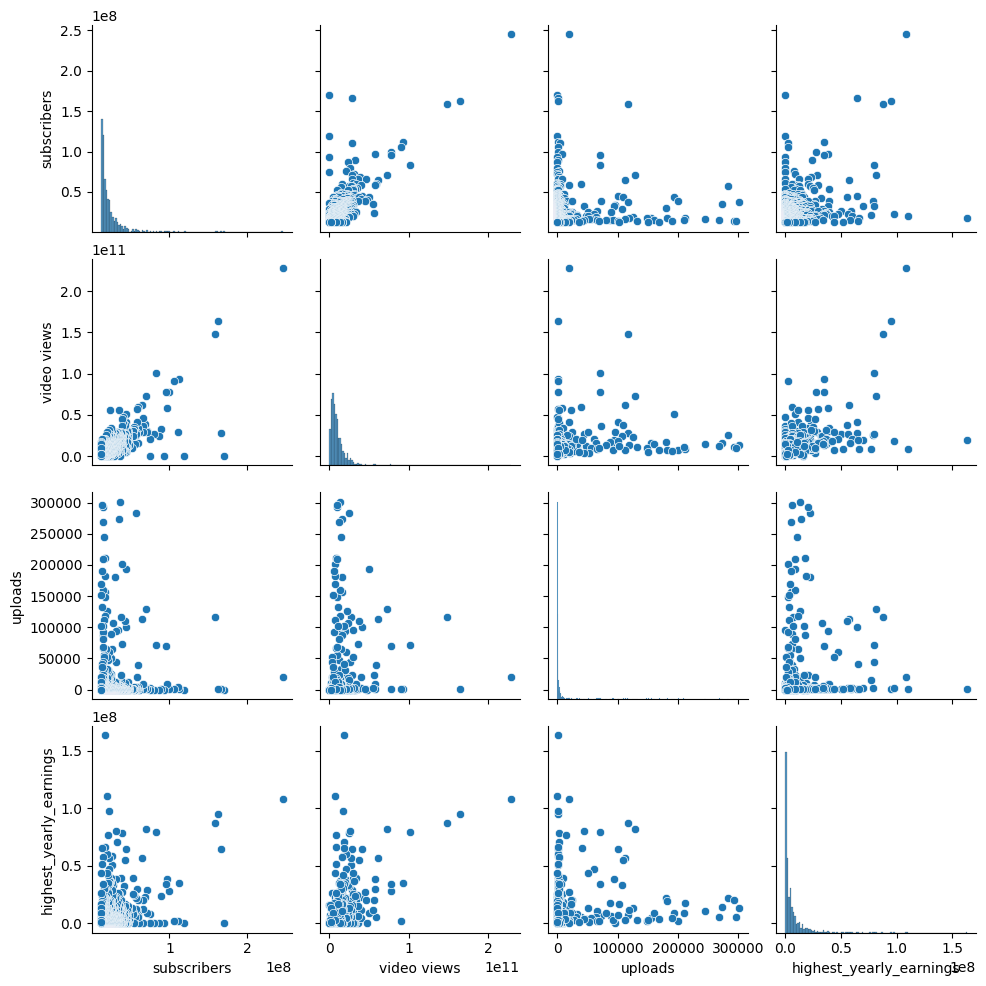

In [56]:
selected_features = [
    'subscribers',
    'video views',
    'uploads',
    'highest_yearly_earnings'
]

sns.pairplot(df[selected_features])

plt.show()

###**Key Insights**:
• Entertainment and Music channels were among the most dominant categories on YouTube in terms of subscribers and video views.

• Channels with higher subscriber counts generally achieved significantly higher video views and yearly earnings.

• Strong positive correlations were observed between subscribers, video views, and yearly earnings, indicating that audience reach directly impacts revenue generation.

• The United States had the highest number of popular YouTube channels and contributed significantly to total subscribers and earnings.

• Channels with more uploads did not always guarantee higher subscribers, suggesting that content quality and audience engagement are also important factors.

• Most YouTube channels were created after 2010, showing rapid platform growth over the last decade.

• Certain channel types consistently generated higher yearly earnings compared to others, highlighting differences in monetization opportunities across content categories.

• Distribution plots and boxplots revealed the presence of extreme outliers in subscribers, earnings, and video views, which is common in social media analytics datasets.

• Correlation heatmaps and scatterplots showed strong relationships between key performance metrics such as subscribers, views, uploads, and earnings.

• The dataset demonstrated how data analytics can be used to understand audience behavior, creator growth patterns, and platform-level business trends.

###**Conclusion**:
This project successfully performed Exploratory Data Analysis (EDA) on the Global YouTube Statistics dataset to identify trends, patterns, correlations, and business insights related to YouTube channels worldwide.

The dataset was preprocessed by handling missing values and preparing numerical and categorical features for analysis. Multiple statistical analyses and visualizations were performed to explore subscriber growth, video views, earnings, uploads, country-wise distributions, category performance, and channel trends.

The analysis revealed strong relationships between subscribers, video views, and revenue generation, highlighting the importance of audience engagement in digital content monetization. The project also demonstrated how data visualization and statistical analysis can provide meaningful insights into content creation trends and social media platform growth.

Overall, this project provided practical experience in data preprocessing, exploratory data analysis, statistical visualization, trend analysis, and business analytics using Python libraries such as Pandas, Matplotlib, and Seaborn.